In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/meruvulikith/190k-spam-ham-email-dataset-for-classification/spam_Emails_data.csv
/kaggle/input/datasets/jackksoncsie/spam-email-dataset/emails.csv
/kaggle/input/datasets/sahideseker/spam-mail-classifier-dataset/spam_mail_classifier.csv


## **Loading Dataset**

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [3]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from nltk import ngrams
from gensim.models import Word2Vec

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay,confusion_matrix, precision_score, accuracy_score

from sklearn.preprocessing import MinMaxScaler, MaxAbsScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import pickle
import re

## **Loading datasets**

In [4]:
df1 = pd.read_csv("/kaggle/input/datasets/meruvulikith/190k-spam-ham-email-dataset-for-classification/spam_Emails_data.csv", nrows=10000)
df1.head()

,label,text
0,Spam,viiiiiiagraaaa\nonly for the ones that want to...
1,Ham,got ice thought look az original message ice o...
2,Spam,yo ur wom an ne eds an escapenumber in ch ma n...
3,Spam,start increasing your odds of success & live s...
4,Ham,author jra date escapenumber escapenumber esca...


In [5]:
df1["text"][3]

'start increasing your odds of success & live sexually healthy .\neasy and imperceptible to take .\ntake just a candy and become ready for 36 hours of love .\n? this is most modern and safe way not to cover with shame\n? only 15 minutes to wait\n? fda approved\nsoft tabs order will be packaged discreetly for your privacy and protection .\nr % emove !\n'

In [6]:
le = LabelEncoder()
df1["label"] = le.fit_transform(df1["label"])

In [7]:
df1["label"].value_counts()

label
0    5291
1    4709
Name: count, dtype: int64

In [8]:
df2 = pd.read_csv("/kaggle/input/datasets/jackksoncsie/spam-email-dataset/emails.csv")
df2 = df2[["spam","text"]].rename({"spam":"label"}, axis=1)
df2.head()

,label,text
0,1,Subject: naturally irresistible your corporate...
1,1,Subject: the stock trading gunslinger fanny i...
2,1,Subject: unbelievable new homes made easy im ...
3,1,Subject: 4 color printing special request add...
4,1,"Subject: do not have money , get software cds ..."


In [9]:
df2.shape

(5728, 2)

In [10]:
df2["text"][2]

'Subject: unbelievable new homes made easy  im wanting to show you this  homeowner  you have been pre - approved for a $ 454 , 169 home loan at a 3 . 72 fixed rate .  this offer is being extended to you unconditionally and your credit is in no way a factor .  to take advantage of this limited time opportunity  all we ask is that you visit our website and complete  the 1 minute post approval form  look foward to hearing from you ,  dorcas pittman'

In [11]:
df2["label"].value_counts()

label
0    4360
1    1368
Name: count, dtype: int64

In [12]:
df3 = pd.read_csv("/kaggle/input/datasets/sahideseker/spam-mail-classifier-dataset/spam_mail_classifier.csv")
df3 = df3[["label","email_text"]].rename({"email_text":"text"}, axis=1)
df3.head()

,label,text
0,ham,Let's catch up sometime next week!
1,ham,Don't forget to submit your project by Friday.
2,spam,Win a free iPhone now!!! Click here.
3,ham,Can you send me the report when it's ready?
4,ham,Meeting has been rescheduled to next Monday.


In [13]:
df3["text"][6]

"Can you send me the report when it's ready?"

In [14]:
le = LabelEncoder()
df3["label"] = le.fit_transform(df3["label"])

In [15]:
df3["label"].value_counts()

label
0    583
1    417
Name: count, dtype: int64

## **Concatenating all datasets**

In [16]:
df = pd.concat([df2,df1,df3], axis=0).reset_index(drop=True)
df.head()

,label,text
0,1,Subject: naturally irresistible your corporate...
1,1,Subject: the stock trading gunslinger fanny i...
2,1,Subject: unbelievable new homes made easy im ...
3,1,Subject: 4 color printing special request add...
4,1,"Subject: do not have money , get software cds ..."


In [17]:
df.shape

(16728, 2)

## **Text Preprocessing**

In [18]:
df["label"].value_counts()

label
0    10234
1     6494
Name: count, dtype: int64

In [19]:
df["text"][9]

'Subject: save your money buy getting this thing here  you have not tried cialls yet ?  than you cannot even imagine what it is like to be a real man in bed !  the thing is that a great errrectlon is provided for you exactiy when you want .  cialis has a lot of advantages over viagra  - the effect lasts 36 hours !  - you are ready to start within just 10 minutes !  - you can mix it with aicohoi ! we ship to any country !  get it right now ! . '

In [20]:
# Checking shape of dataset

df.shape

(16728, 2)

In [21]:
# Checking duplicates values in dataset

df.duplicated().sum()

np.int64(1023)

In [22]:
# Droping duplicates values

df = df.drop_duplicates(keep = "first")

In [23]:
# Again checking duplicates values after removing duplicates
df.duplicated().sum()

np.int64(0)

In [24]:
# checking dataset shape after droping duplicates values

df.shape

(15705, 2)

In [25]:
df["label"].value_counts()

label
0    9623
1    6082
Name: count, dtype: int64

In [26]:
# Checking null  values in dataset

df.isnull().sum()

label    0
text     0
dtype: int64

# **EDA**

## **Checking for, is dataset balanced or imbalanced ?**

In [27]:
df["label"].value_counts()

label
0    9623
1    6082
Name: count, dtype: int64

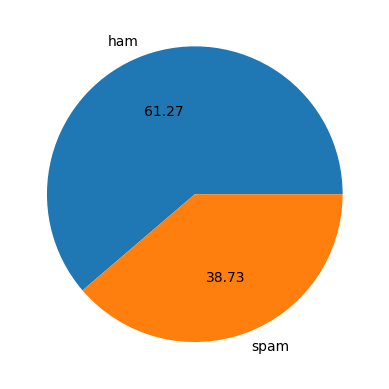

In [28]:
plt.pie(df["label"].value_counts(), autopct="%.2f", labels=["ham", "spam"])
plt.show()

### **We can see our dataset is imbalanced**

#### **Dictionary for chat words, full words of short words, english contraction words, suffix and preffix words, and other words**

In [29]:
Words_dict = {
    'u': 'you',
    'c': 'see',
    'r': 'are',
    'y': 'yes',
    'k': 'okay',
    'b': 'be',
    'd': 'the',
    'n': 'and',
    'm': 'am',
    'o': 'ok',
    't': 'tea',
    'x': 'kiss',
    'z': 'snooze',
    '2day': 'today',
    '2nyt': 'tonight',
    '2mro': 'tomorrow',
    '2gether': 'together',
    '4ever': 'forever',
    '4get': 'forget',
    '4give': 'forgive',
    '4ward': 'forward',
    '4u': 'for you',
    'b4': 'before',
    'gr8': 'great',
    'h8': 'hate',
    'w8': 'wait',
    'str8': 'straight',
    'l8': 'late',
    'l8r': 'later',
    'm8': 'mate',
    'cr8': 'create',
    'sk8': 'skate',
    '1ce': 'once',
    'ne1': 'anyone',
    'sum1': 'someone',
    'every1': 'everyone',
    'no1': 'no one',
    '2moro': 'tomorrow',
    '2night': 'tonight',
    'gm': 'good morning',
    'gn': 'good night',
    'ga': 'good afternoon',
    'ge': 'good evening',
    'hey': 'hello',
    'heyy': 'hello',
    'yo': 'years old',
    'sup': 'what is up',
    'wassup': 'what is up',
    'wsup': 'what is up',
    'wdup': 'what is up',
    'hiya': 'hello',
    'heya': 'there',
    'hbd': 'happy birthday',
    'bday': 'birthday',
    'lol': 'laughing out loud',
    'lmao': 'laughing my ass off',
    'rofl': 'rolling on the floor laughing',
    'lmfao': 'laughing my ass off',
    'haha': 'laugh',
    'hahaha': 'laugh',
    'hehe': 'laugh',
    'hehehe': 'laugh',
    'loll': 'laugh',
    'lmaoo': 'laugh',
    'kk': 'okay',
    'az': 'as',
    'ok': 'okay',
    'okie': 'okay',
    'okies': 'okay',
    'oki': 'okay',
    'okk': 'okay',
    'alr': 'alright',
    'alrighty': 'alright',
    'aight': 'alright',
    'aite': 'alright',
    'iight': 'alright',
    'ty': 'thank you',
    'thx': 'thanks',
    'tnx': 'thanks',
    'thnx': 'thanks',
    'thnks': 'thanks',
    'tysm': 'thank you so much',
    'tyvm': 'thank you very much',
    'yw': 'you are welcome',
    'np': 'no problem',
    'sry': 'sorry',
    'srry': 'sorry',
    'soz': 'sorry',
    'mybad': 'my mistake',
    'apols': 'apologies',
    'ya': 'yes',
    'yaa': 'yes',
    'yup': 'yes',
    'yep': 'yes',
    'yea': 'yes',
    'yeah': 'yes',
    'yh': 'yeah',
    'ye': 'yes',
    'nah': 'no',
    'nope': 'no',
    'nop': 'no',
    'na': 'no',
    'pls': 'please',
    'plz': 'please',
    'tho': 'though',
    'thru': 'through',
    'nite': 'night',
    'nyt': 'night',
    'lite': 'light',
    'rite': 'right',
    'ryt': 'right',
    'luv': 'love',
    'lv': 'love',
    'hv': 'have',
    'hav': 'have',
    'hvnt': 'have not',
    'wud': 'would',
    'wudnt': 'would not',
    'cud': 'could',
    'cudnt': 'could not',
    'shud': 'should',
    'shudnt': 'should not',
    'wil': 'will',
    'wont': 'will not',
    'cant': 'can not',
    'dont': 'do not',
    'doesnt': 'does not',
    'didnt': 'did not',
    'isnt': 'is not',
    'wasnt': 'was not',
    'hasnt': 'has not',
    'havent': 'have not',
    'wouldnt': 'would not',
    'couldnt': 'could not',
    'shouldnt': 'should not',
    'gud': 'good',
    'tmrw': 'tomorrow',
    'tmr': 'tomorrow',
    'bt': 'but',
    'nt': 'not',
    'bcoz': 'because',
    'bcz': 'because',
    'bc': 'because',
    'coz': 'because',
    'cos': 'because',
    'cuz': 'because',
    'ppl': 'people',
    'pic': 'picture',
    'vid': 'video',
    'msg': 'message',
    'msgd': 'messaged',
    'msgng': 'messaging',
    'txt': 'text',
    'fav': 'favorite',
    'bsy': 'busy',
    'sec': 'second',
    'abt': 'about',
    'abd': 'about',
    'aftr': 'after',
    'agn': 'again',
    'alrdy': 'already',
    'alwys': 'always',
    'smtym': 'sometime',
    'smtms': 'sometimes',
    'sumtym': 'sometime',
    'evry': 'every',
    'evn': 'even',
    'esp': 'especially',
    'exc': 'except',
    'diff': 'different',
    'defn': 'definitely',
    'def': 'definitely',
    'prob': 'problem',
    'probs': 'probably',
    'obv': 'obviously',
    'obvs': 'obviously',
    'srsly': 'seriously',
    'srs': 'serious',
    'rly': 'really',
    'rlly': 'really',
    'kinda': 'kind of',
    'sorta': 'sort of',
    'lotta': 'lot of',
    'outta': 'out of',
    'meh': 'indifferent',
    'rn': 'right now',
    'rq': 'real quick',
    'ngl': 'not gonna lie',
    'tbh': 'to be honest',
    'imo': 'in my opinion',
    'imho': 'in my humble opinion',
    'idk': 'i do not know',
    'idc': 'i do not care',
    'ikr': 'i know right',
    'ik': 'i know',
    'jk': 'just kidding',
    'nvm': 'never mind',
    'tmi': 'too much information',
    'btw': 'by the way',
    'fyi': 'for your information',
    'irl': 'in real life',
    'afaik': 'as far as i know',
    'iirc': 'if i recall correctly',
    'tldr': 'too long did not read',
    'eli5': 'explain like i am 5',
    'ftw': 'for the win',
    'fwiw': 'for what it is worth',
    'lgtm': 'looks good to me',
    'nsfw': 'not safe for work',
    'nsfl': 'not safe for life',
    'aka': 'also known as',
    'std': 'standard',
    'info': 'information',
    'wif': 'with',
    'omg': 'oh my god',
    'omfg': 'oh my god',
    'omgg': 'oh my god',
    'wtf': 'what the hell',
    'wth': 'what the heck',
    'smh': 'shaking my head',
    'facepalm': 'disappointed',
    'rip': 'rest in peace',
    'yay': 'happy',
    'woo': 'excited',
    'yayy': 'excited',
    'ily': 'i love you',
    'ilu': 'i love you',
    'ily2': 'i love you too',
    'xoxo': 'hugs and kisses',
    'muah': 'kiss',
    'luv u': 'love you',
    'bae': 'before anyone else',
    'ur': 'your',
    'urs': 'yours',
    'urself': 'yourself',
    'uself': 'yourself',
    'im': 'i am',
    'iam': 'i am',
    'ima': 'i am going to',
    'imma': 'i am going to',
    'ill': 'i will',
    'id': 'i would',
    'ive': 'i have',
    'its': 'it is',
    'itll': 'it will',
    'tht': 'that',
    'dis': 'this',
    'dat': 'that',
    'dese': 'these',
    'dose': 'those',
    'dem': 'them',
    'der': 'there',
    'dey': 'they',
    'wid': 'with',
    'wit': 'with',
    'w': 'with',
    'wo': 'without',
    'w/o': 'without',
    'w/': 'with',
    'hw': 'how',
    'whr': 'where',
    'wer': 'where',
    'wen': 'when',
    'whn': 'when',
    'wat': 'what',
    'wt': 'what',
    'wats': 'what is',
    'whats': 'what is ',
    'whos': 'who is',
    'hows': 'how is',
    'hav2': 'have to',
    'hafta': 'have to',
    'gotta': 'got to',
    'gonna': 'going to',
    'wanna': 'want to',
    'dunno': 'do not know',
    'lemme': 'let me',
    'gimme': 'give me',
    'cmon': 'come on',
    'cmn': 'come on',
    'whatcha': 'what are you',
    'wyd': 'what are you doing',
    'wru': 'where are you',
    'wya': 'where you at',
    'wbu': 'what about you',
    'hbu': 'how about you',
    'hru': 'how are you',
    'oni': 'only',
    'brb': 'be right back',
    'bbl': 'be back later',
    'ttyl': 'talk to you later',
    'ttys': 'talk to you soon',
    'afk': 'away from keyboard',
    'atm': 'at the moment',
    'asap': 'as soon as possible',
    'eta': 'estimated time of arrival',
    'bbs': 'be back soon',
    'tyt': 'take your time',
    'eod': 'end of day',
    'eow': 'end of week',
    'bf': 'boyfriend',
    'gf': 'girlfriend',
    'bff': 'best friends forever',
    'bffl': 'best friend for life',
    'bro': 'brother',
    'sis': 'sister',
    'fam': 'family',
    'crush': 'someone you like',
    'fwb': 'friends with benefits',
    'ex': 'ex partner',
    'boo': 'significant other',
    'situationship': 'undefined relationship',
    'ick': 'sudden turn off',
    'fomo': 'fear of missing out',
    'yolo': 'you only live once',
    'lit': 'amazing',
    'dope': 'cool',
    'savage': 'bold',
    'flex': 'show off',
    'ghosting': 'ignoring messages',
    'ghosted': 'ignored',
    'stan': 'super fan',
    'mood': 'relatable feeling',
    'slay': 'doing great',
    'bet': 'agreed',
    'fax': 'facts',
    'facts': 'truth',
    'cap': 'lie',
    'nocap': 'no lie',
    'bussin': 'really good',
    'catfish': 'fake identity online',
    'finsta': 'fake instagram',
    'sus': 'suspicious',
    'npc': 'non playable character',
    'pov': 'point of view',
    'gg': 'good game',
    'gl': 'good luck',
    'hf': 'have fun',
    'ez': 'easy',
    'wp': 'well played',
    'noob': 'beginner',
    'pro': 'professional',
    'op': 'overpowered',
    'nerf': 'reduce power',
    'l': 'loss',
    'dm': 'decimeter',
    'pm': 'private message',
    'post': 'publish',
    'dp': 'display picture',
    'pfp': 'profile picture',
    'ss': 'screenshot',
    'tl': 'timeline',
    'rt': 'retweet',
    'qrt': 'quote retweet',
    'ig': 'instagram',
    'yt': 'youtube',
    'fb': 'facebook',
    'wa': 'whatsapp',
    'bio': 'biography',
    'promo': 'promotion',
    'ad': 'advertisement',
    'sp': 'sponsored post',
    'og': 'original',
    'link': 'website url',
    'ootd': 'outfit of the day',
    'potd': 'photo of the day',
    'qotd': 'quote of the day',
    'wotd': 'word of the day',
    'sotd': 'song of the day',
    'tbt': 'throwback thursday',
    'wcw': 'woman crush wednesday',
    'mcm': 'man crush monday',
    'fbf': 'flashback friday',
    'wfh': 'work from home',
    'ooo': 'out of office',
    'pto': 'paid time off',
    'kpi': 'key performance indicator',
    'tbd': 'to be decided',
    'tba': 'to be announced',
    'poc': 'point of contact',
    'fyr': 'for your reference',
    'rsvp': 'please reply',
    'cc': 'carbon copy',
    'bcc': 'blind carbon copy',
    'mgr': 'manager',
    'org': 'organization',
    'corp': 'corporate',
    'emp': 'employee',
    'hr': 'human resources',
    'proj': 'project',
    'rpt': 'report',
    'pres': 'presentation',
    'doc': 'document',
    'conf': 'conference',
    'mtg': 'meeting',
    'clnt': 'client',
    'biz': 'business',
    'ops': 'operations',
    'acct': 'account',
    'fin': 'finance',
    'mktg': 'marketing',
    'sal': 'salary',
    'perf': 'performance',
    'amt': 'amount',
    'bal': 'balance',
    'txn': 'transaction',
    'pymt': 'payment',
    'invce': 'invoice',
    'rcpt': 'receipt',
    'disc': 'discount',
    'chrg': 'charge',
    'refnd': 'refund',
    'bgt': 'budget',
    'expns': 'expenses',
    'prof': 'profit',
    'rev': 'revenue',
    'emi': 'equated monthly installment',
    'fwd': 'forward',
    'rply': 'reply',
    'ack': 'acknowledge',
    'ntfy': 'notify',
    'updt': 'update',
    'dtls': 'details',
    'cnfrm': 'confirm',
    'req': 'request',
    'resp': 'response',
    'ques': 'question',
    'ans': 'answer',
    'expl': 'explanation',
    'asf': 'as fuck',
    'subj': 'subject',
    'chpt': 'chapter',
    'assgn': 'assignment',
    'hmwk': 'homework',
    'exm': 'exam',
    'rvs': 'revision',
    'ref': 'reference',
    'lib': 'library',
    'clg': 'college',
    'univ': 'university',
    'cert': 'certificate',
    'qlf': 'qualification',
    'deg': 'degree',
    'res': 'result',
    'ppr': 'paper',
    'sys': 'system',
    'db': 'database',
    'srv': 'server',
    'app': 'application',
    'dev': 'development',
    'prog': 'program',
    'algo': 'algorithm',
    'func': 'function',
    'var': 'variable',
    'obj': 'object',
    'cfg': 'configuration',
    'repo': 'repository',
    'ver': 'version',
    'upg': 'upgrade',
    'bkp': 'backup',
    'err': 'error',
    'dbg': 'debug',
    'api': 'application programming interface',
    'brkfst': 'breakfast',
    'lnch': 'lunch',
    'dnr': 'dinner',
    'snck': 'snack',
    'groc': 'groceries',
    'veg': 'vegetables',
    'frt': 'fruit',
    'restn': 'restaurant',
    'dlvry': 'delivery',
    'ordr': 'order',
    'gym': 'gymnasium',
    'wrkout': 'workout',
    'exrc': 'exercise',
    'med': 'medicine',
    'hosp': 'hospital',
    'sym': 'symptoms',
    'diag': 'diagnosis',
    'presc': 'prescription',
    'vitl': 'vitals',
    'bp': 'blood pressure',
    'tkts': 'tickets',
    'bkng': 'booking',
    'rsrv': 'reserve',
    'dept': 'departure',
    'arrv': 'arrival',
    'dest': 'destination',
    'pkg': 'package',
    'acc': 'accommodation',
    'trvl': 'travel',
    'pspt': 'passport',
    'wkly': 'weekly',
    'mnthly': 'monthly',
    'yrly': 'yearly',
    'dly': 'daily',
    'hrs': 'hours',
    'mins': 'minutes',
    'secs': 'seconds',
    'ystdy': 'yesterday',
    'tdy': 'today',
    'wknd': 'weekend',
    'wk': 'week',
    'mth': 'month',
    'yr': 'year',
    'qt': 'quarter',
    'sched': 'schedule',
    'appt': 'appointment',
    'dlne': 'deadline',
    'addr': 'address',
    'ph': 'potential of hydrogen',
    'num': 'number',
    'lang': 'language',
    'govt': 'government',
    'natl': 'national',
    'intl': 'international',
    'loc': 'location',
    'dist': 'distance',
    'dirn': 'direction',
    'cty': 'city',
    'st': 'first',
    'cntry': 'country',
    'pop': 'population',
    'temp': 'temperature',
    'wthr': 'weather',
    'env': 'environment',
    'soln': 'solution',
    'mvp': 'most valuable person',
    'awsm': 'awesome',
    'grats': 'congratulations',
    'congrats': 'congratulations',
    'tc': 'take care',
    'wb': 'welcome back',
    'fne': 'fine',
    'gd': 'good',
    'gr': 'great',
    'aws': 'awesome',
    'cul': 'cool',
    'kewl': 'cool',
    'nce': 'nice',
    'mad': 'extremely',
    'bare': 'very',
    'dead': 'very funny',
    'lowk': 'lowkey',
    'hk': 'highkey',
    'hmu': 'hit me up',
    'lmk': 'let me know',
    'fr': 'for real',
    'ong': 'on god seriously',
    'iykyk': 'if you know you know',
    'istg': 'i swear to god',
    'jkjk': 'just kidding just kidding',
    'nbd': 'no big deal',
    'ofc': 'of course',
    'cya': 'see you around',
    "t&c's": 'terms and conditions',
    't&c': 'terms and conditions',
    "i'm": 'i am',
    "you're": 'you are',
    "he's": 'he is',
    "she's": 'she is',
    "it's": 'it is',
    "we're": 'we are',
    "they're": 'they are',
    "that's": 'that is',
    "what's": 'what is',
    "who's": 'who is',
    "where's": 'where is',
    "when's": 'when is',
    "why's": 'why is',
    "how's": 'how is',
    "here's": 'here is',
    "there's": 'there is',
    "this's": 'this is',
    "name's": 'name is',
    "one's": 'one is',
    "someone's": 'someone is',
    "everyone's": 'everyone is',
    "nobody's": 'nobody is',
    "anybody's": 'anybody is',
    "i'll": 'i will',
    "you'll": 'you will',
    "he'll": 'he will',
    "she'll": 'she will',
    "it'll": 'it will',
    "we'll": 'we will',
    "they'll": 'they will',
    "that'll": 'that will',
    "who'll": 'who will',
    "what'll": 'what will',
    "where'll": 'where will',
    "when'll": 'when will',
    "this'll": 'this will',
    "there'll": 'there will',
    "i've": 'i have',
    "you've": 'you have',
    "we've": 'we have',
    "they've": 'they have',
    "could've": 'could have',
    "would've": 'would have',
    "should've": 'should have',
    "might've": 'might have',
    "must've": 'must have',
    "who've": 'who have',
    "what've": 'what have',
    "where've": 'where have',
    "when've": 'when have',
    "how've": 'how have',
    "i'd": 'i would',
    "you'd": 'you would',
    "he'd": 'he would',
    "she'd": 'she would',
    "it'd": 'it would',
    "we'd": 'we would',
    "they'd": 'they would',
    "that'd": 'that would',
    "who'd": 'who would',
    "what'd": 'what did',
    "where'd": 'where did',
    "when'd": 'when did',
    "why'd": 'why did',
    "how'd": 'how did',
    "don't": 'do not',
    "doesn't": 'does not',
    "didn't": 'did not',
    "isn't": 'is not',
    "aren't": 'are not',
    "wasn't": 'was not',
    "weren't": 'were not',
    "won't": 'will not',
    "wouldn't": 'would not',
    "can't": 'can not',
    'cannot': 'can not',
    "couldn't": 'could not',
    "shouldn't": 'should not',
    "hasn't": 'has not',
    "haven't": 'have not',
    "hadn't": 'had not',
    "mustn't": 'must not',
    "mightn't": 'might not',
    "needn't": 'need not',
    "shan't": 'shall not',
    "daren't": 'dare not',
    "oughtn't": 'ought not',
    "mayn't": 'may not',
    "ain't": 'am not',
    "won't've": 'will not have',
    "don't've": 'do not have',
    "wouldn't've": 'would not have',
    "couldn't've": 'could not have',
    "shouldn't've": 'should not have',
    "mustn't've": 'must not have',
    "i'd've": 'i would have',
    "you'd've": 'you would have',
    "he'd've": 'he would have',
    "she'd've": 'she would have',
    "we'd've": 'we would have',
    "they'd've": 'they would have',
    "i'll've": 'i will have',
    "you'll've": 'you will have',
    "he'll've": 'he will have',
    "she'll've": 'she will have',
    "we'll've": 'we will have',
    "they'll've": 'they will have',
    "it'll've": 'it will have',
    "that'll've": 'that will have',
    "who'll've": 'who will have',
    'watcha': 'what are you',
    'whacha': 'what are you',
    'whaddya': 'what do you',
    'whatdya': 'what do you',
    'howdya': 'how do you',
    'whydya': 'why do you',
    'wheredya': 'where do you',
    'whendya': 'when do you',
    'whoddya': 'who do you',
    'didja': 'did you',
    'wouldja': 'would you',
    'couldja': 'could you',
    'shouldja': 'should you',
    'dontcha': 'do not you',
    'doncha': 'do not you',
    'cantcha': 'can not you',
    'gotcha': 'got you',
    'getcha': 'get you',
    'letcha': 'let you',
    'betcha': 'bet you',
    'atcha': 'at you',
    'hitcha': 'hit you',
    'hasta': 'has to',
    'oughta': 'ought to',
    'sposta': 'supposed to',
    'supposta': 'supposed to',
    'needta': 'need to',
    'useta': 'used to',
    'usta': 'used to',
    'tryna': 'trying to',
    'finna': 'fixing to going to',
    'bouta': 'about to',
    'bout to': 'about to',
    'coupla': 'couple of',
    'buncha': 'bunch of',
    'lil': 'little',
    "lil'": 'little',
    "ol'": 'old',
    'ol': 'old',
    "nothin'": 'nothing',
    "somethin'": 'something',
    "everythin'": 'everything',
    'nothin': 'nothing',
    'somethin': 'something',
    'everythin': 'everything',
    "anythin'": 'anything',
    'anythin': 'anything',
    'lemme know': 'let me know',
    'gimme a sec': 'give me a second',
    'lemme see': 'let me see',
    'lemme think': 'let me think',
    'lemme check': 'let me check',
    'tellme': 'tell me',
    'showme': 'show me',
    'takeme': 'take me',
    'bringme': 'bring me',
    'helpme': 'help me',
    'letme': 'let me',
    'innit': 'is it not',
    'init': 'is it not',
    'innit though': 'is it not though',
    'aint it': 'is it not',
    'nuh': 'no',
    'huh': 'yes',
    'uh': 'microhenry',
    'mm': 'millimeter',
    'mmm': 'yes thinking',
    'hmm': 'thinking',
    'hm': 'thinking',
    'erm': 'hesitation',
    'um': 'hesitation',
    'oh': 'expression of mistake',
    'oops': 'expression of mistake',
    'whoops': 'expression of mistake',
    'oopsie': 'small mistake',
    'oof': 'expression of pain',
    'yikes': 'expression of shock',
    'eek': 'expression of fear',
    'eww': 'expression of disgust',
    'ew': 'expression of disgust',
    'ugh': 'expression of frustration',
    'ughhh': 'extreme frustration',
    'bleh': 'expression of dislike',
    'blah': 'boring or unwell',
    'phew': 'expression of relief',
    'whew': 'expression of relief',
    'hooray': 'expression of joy',
    'woohoo': 'expression of excitement',
    'woah': 'expression of surprise',
    'whoa': 'expression of surprise',
    'wow': 'expression of amazement',
    'aww': 'expression of affection',
    'awww': 'expression of affection',
    'awe': 'feeling of wonder',
    'hihi': 'giggling',
    "'cause": 'because',
    'thro': 'through',
    'tonite': 'tonight',
    'alrite': 'alright',
    'alright': 'all right',
    'mkay': 'okay',
    "m'kay": 'okay',
    'defo': 'definitely',
    'defs': 'definitely',
    'realy': 'really',
    'prolly': 'probably',
    'tbf': 'to be fair',
    'gtg': 'got to go',
    "y'all": 'you all',
    "ya'll": 'you all',
    'yall': 'you all',
    "all y'all": 'all of you',
    'fixin to': 'going to',
    'fixing to': 'going to',
    'reckon': 'think believe',
    'reckoned': 'thought believed',
    'folks': 'people family',
    'howdy': 'hello',
    "hey y'all": 'hello everyone',
    "c'mon": 'come on',
    "c'mere": 'come here',
    'cmere': 'come here',
    "g'day": 'good day',
    "s'up": 'what is up',
    "s'all": 'it is all',
    'fo': 'for',
    'pal': 'friend',
    'ta': 'thank you',
    'mo': 'moment',
    'cheerio': 'goodbye',
    'toodle': 'goodbye',
    'pip': 'goodbye',
    'brill': 'brilliant',
    'pronto': 'immediately quickly',
    'yest': 'yesterday',
    '2nite': 'tonight',
    'min': 'minute',
    'gator': 'later',
    'gme': 'good morning everyone',
    'gne': 'good night everyone',
    'heyyyy': 'hello',
    'hlo': 'hello',
    'hlw': 'hello',
    'helo': 'hello',
    'heyyy': 'hello',
    'hy': 'hello',
    'namaste': 'hello greetings',
    'nmsth': 'namaste',
    'nm': 'nothing much',
    'wlcm': 'welcome',
    'byee': 'goodbye',
    'byeee': 'goodbye',
    'tata': 'goodbye',
    'alvida': 'goodbye',
    'shubh': 'good',
    'ratri': 'night',
    'prabhat': 'morning',
    'subah': 'morning',
    'raat': 'night',
    'morning': 'good morning',
    'gn8': 'good night',
    'hal': 'situation',
    'haal': 'situation',
    'kaisa': 'how',
    'kaisi': 'how',
    'ho': 'are you',
    'kaise': 'how',
    'sab': 'everything',
    'theek': 'fine',
    'thk': 'fine',
    'badhiya': 'great',
    'mast': 'great',
    'ekdum': 'absolutely',
    'bilkul': 'absolutely',
    'thoda': 'a little',
    'bahut': 'very',
    'pakka': 'sure confirmed',
    'pucca': 'sure confirmed',
    'sahi': 'correct',
    'sach': 'truth',
    'sachchi': 'really truly',
    'haan': 'yes',
    'ha': 'yes',
    'haa': 'yes',
    'hanji': 'yes respectful',
    'ji': 'yes',
    'hn': 'yes',
    'hmmm': 'yes',
    'hmmmm': 'yes',
    'zaroor': 'definitely',
    'zarur': 'definitely',
    'oky': 'okay',
    'acha': 'okay',
    'achha': 'okay',
    'accha': 'okay',
    'hmmk': 'okay',
    'kkk': 'okay',
    'okkkk': 'okay',
    'nahi': 'no',
    'nhi': 'no',
    'nai': 'no',
    'nh': 'no',
    'mat': 'do not',
    'kabhi': 'never',
    'aise': 'like this',
    'galat': 'wrong',
    'glt': 'wrong',
    'thanx': 'thanks',
    'sryy': 'sorry',
    'soory': 'sorry',
    'maafi': 'sorry apology',
    'maaf': 'please forgive',
    'mafi': 'sorry',
    'galti': 'mistake',
    'bhool': 'forgot',
    'mai': 'i',
    'main': 'i',
    'tu': 'you',
    'tum': 'you',
    'tm': 'you',
    'tumh': 'you',
    'tumhe': 'you',
    'mera': 'my',
    'se': 'from',
    'dil': 'heart',
    'karna': 'do',
    'kiya': 'did',
    'kr': 'do',
    'kro': 'do',
    'krna': 'do',
    'krunga': 'will do',
    'aa': 'come',
    'aaja': 'come here',
    'aao': 'come',
    'aja': 'come',
    'ja': 'go',
    'jaa': 'go',
    'jao': 'go',
    'ruk': 'stop',
    'bolo': 'say',
    'bol': 'say',
    'bta': 'tell',
    'btao': 'tell',
    'bata': 'tell me',
    'batao': 'tell us',
    'sun': 'listen',
    'suno': 'listen',
    'samjha': 'understand',
    'samjhi': 'understood',
    'samjh': 'understand',
    'pata': 'know',
    'nikal': 'leave',
    'nikl': 'leave',
    'milte': 'meet',
    'diya': 'give',
    'churaya': 'stole',
    'dun': 'done',
    'abi': 'now',
    'ab': 'now',
    'abhi': 'now',
    'tb': 'then',
    'thodi': 'little',
    'jaldi': 'quickly',
    '2mrw': 'tomorrow',
    'kal': 'tomorrow',
    'parso': 'day after tomorrow',
    'aaj': 'today',
    'baad': 'later',
    'kya': 'what',
    'kab': 'when',
    'kahan': 'where',
    'kuch': 'some',
    'koi': 'someone',
    'yaar': 'friend',
    'yrr': 'friend',
    'dost': 'friend',
    'chill': 'relax',
    'relax': 'calm down',
    'tension': 'stress',
    'scene': 'situation',
    'soch': 'think',
    'wht': 'what',
    'jugaad': 'creative hack',
    'topper': 'top ranker',
    'chapri': 'low class person',
    'chutiyapa': 'nonsense',
    'bakwaas': 'nonsense',
    'bakwas': 'nonsense',
    'bkws': 'nonsense',
    'faltu': 'useless',
    'bekar': 'useless',
    'bekaar': 'useless',
    'ajeeb': 'strange',
    'pagal': 'crazy',
    'paagal': 'crazy',
    'pagalpan': 'craziness',
    'ullu': 'fool',
    'gadha': 'fool',
    'bewakoof': 'stupid',
    'anpadh': 'uneducated',
    'andha': 'blind ignorant',
    'bakar': 'nonsense',
    'bakr': 'nonsense',
    'chup': 'quiet',
    'attitude': 'arrogance',
    'dikhawe': 'showoff',
    'nakhra': 'attitude',
    'nakhre': 'tantrums',
    'drama': 'unnecessary fuss',
    'nautanki': 'overdramatic',
    'overacting': 'too much drama',
    'timepass': 'killing time',
    'tp': 'timepass',
    'masti': 'fun',
    'dhamaal': 'fun chaos',
    'mazaa': 'fun',
    'maja': 'fun',
    'bindass': 'carefree cool',
    'jhooth': 'lie',
    'jhoota': 'liar male',
    'jhooti': 'liar female',
    'zyada': 'too much',
    'itna': 'that much',
    'kaam': 'work',
    'chutti': 'holiday',
    'paisa': 'money',
    'paise': 'money',
    'kharch': 'expense',
    'bachat': 'savings',
    'udhaar': 'loan',
    'arrey': 'hey oh',
    'bhai': 'brother',
    'arre': 'hey oh',
    'uff': 'frustration',
    'uffff': 'extreme frustration',
    'oho': 'surprised',
    'oye': 'hey',
    'arey': 'hey',
    'ram': 'god',
    'allah': 'god',
    'bas': 'stop',
    'wah': 'great',
    'shabash': 'well done',
    'zabardast': 'amazing',
    'kamaal': 'wonderful',
    'jhakaas': 'awesome',
    'bindaas': 'carefree',
    'baap': 'father',
    'aisa': 'like this',
    'wohoo': 'excited',
    'damn': 'anger expression',
    'bruh': 'brother',
    'umm': 'thinking',
    'eh': 'question',
    'xd': 'laugh face',
    'ded': 'dead laughing',
    'dying': 'laughing so hard',
    'hasi': 'laughing',
    'hans': 'laughing',
    'paet': 'stomach',
    'dard': 'pain',
    'ilysm': 'i love you so much',
    'lvu': 'love you',
    'mwah': 'kiss',
    'pyaar': 'love',
    'pyar': 'love',
    'ishq': 'deep love',
    'mohabbat': 'deep love',
    'jaan': 'dear life',
    'jaanu': 'darling',
    'babu': 'dear baby',
    'shona': 'darling',
    'sona': 'dear',
    'puchku': 'cute dear',
    'cutu': 'cute one',
    'cutie': 'cute person',
    'sweetheart': 'dear',
    'pataka': 'stunning person',
    'broo': 'brother',
    'bhaiya': 'elder brother',
    'didi': 'sister',
    'bhaijaan': 'dear brother',
    'bhabhi': 'sister in law',
    'jiju': 'brother in law',
    'mama': 'maternal uncle',
    'mami': 'maternal aunt',
    'chacha': 'paternal uncle',
    'chachi': 'paternal aunt',
    'nana': 'maternal grandfather',
    'nani': 'maternal grandmother',
    'dada': 'paternal grandfather',
    'dadi': 'paternal grandmother',
    'hubby': 'husband',
    'wifey': 'wife',
    'bestie': 'best friend',
    'besti': 'best friend',
    'tussi': 'you respectful',
    'changa': 'good',
    'changaa': 'good',
    'ssa': 'sat sri akal',
    'waheguru': 'god expression',
    'paaji': 'elder brother',
    'paji': 'brother friend',
    'pendu': 'village person',
    'gaddi': 'car vehicle',
    'thayu': 'done happened',
    'ben': 'sister',
    'dikra': 'dear son',
    'vatata': 'feels like',
    'changlya': 'good',
    'wfo': 'work from office',
    'tg': 'telegram',
    'tt': 'tiktok',
    'grwm': 'get ready with me',
    'asmr': 'relaxing sound video',
    'viral': 'very popular',
    'trending': 'currently popular',
    'fyp': 'for you page',
    'foryou': 'for you page',
    'explore': 'discovery page',
    'khana': 'food',
    'bhookha': 'hungry',
    'chai': 'tea',
    'maggi': 'instant noodles',
    'roti': 'bread',
    'paratha': 'flatbread',
    'poha': 'flattened rice',
    'idli': 'rice cake',
    'dosa': 'crepe',
    'chaat': 'street food',
    'mithai': 'sweets',
    'barfi': 'indian sweet',
    'halwa': 'sweet dish',
    'kheer': 'rice pudding',
    'nonveg': 'non vegetarian',
    'ghumne': 'travelling',
    'bimar': 'sick',
    'tabiyat': 'health condition',
    'bukhar': 'fever',
    'thaka': 'tired',
    'neend': 'sleep',
    'paani': 'water',
    'dawai': 'medicine',
    'padhai': 'studies',
    'padh': 'study',
    'badhai': 'congratulations',
    'mubarak': 'congratulations',
    'atb': 'all the best',
    'shubhkamnayen': 'best wishes',
    'khush': 'happy',
    'muskurao': 'smile',
    'jio': 'live long',
    'jiyo': 'live long',
    'kasam': 'swear',
    'qasam': 'oath',
    'misc': 'miscellaneous',
    'etc': 'and so on',
    'eg': 'for example',
    'ie': 'that is',
    'ps': 'post script',
    'nb': 'note carefully',
    'af': 'very much',
    'nmu': 'nothing much you',
    'u2': 'you too',
    'same': 'same here',
    'relate': 'i can relate',
    'plzz': 'please',
    'plzzz': 'please',
    'nd': 'second',
    'rd': 'third',
    'wks': 'weeks',
    'mths': 'months',
    'yrs': 'years',
    'yoa': 'years of age',
    'dob': 'date of birth',
    'g': 'gram',
    'kg': 'kilogram',
    'mg': 'milligram',
    'ug': 'microgram',
    'lb': 'pound',
    'lbs': 'pounds',
    'oz': 'ounce',
    'cm': 'centimeter',
    'ft': 'foot',
    'in': 'inch',
    'mi': 'mile',
    'yd': 'yard',
    'ly': 'light year',
    'au': 'astronomical unit',
    'kmh': 'kilometer per hour',
    'kph': 'kilometer per hour',
    'mph': 'mile per hour',
    'mps': 'meter per second',
    'fps': 'feet per second',
    'rpm': 'revolution per minute',
    'rps': 'revolution per second',
    'ml': 'milliliter',
    'cl': 'centiliter',
    'dl': 'deciliter',
    'kl': 'kiloliter',
    'tsp': 'teaspoon',
    'tbsp': 'tablespoon',
    'pt': 'pint',
    'gal': 'gallon',
    'sqm': 'square meter',
    'sqft': 'square foot',
    'sqkm': 'square kilometer',
    'sqmi': 'square mile',
    'sqcm': 'square centimeter',
    'sqmm': 'square millimeter',
    'sqyd': 'square yard',
    'ac': 'acre',
    'kw': 'kilowatt',
    'mw': 'megawatt',
    'gw': 'gigawatt',
    'kwh': 'kilowatt hour',
    'mwh': 'megawatt hour',
    'j': 'joule',
    'kj': 'kilojoule',
    'cal': 'calorie',
    'kcal': 'kilocalorie',
    'btu': 'british thermal unit',
    'hp': 'horsepower',
    'v': 'volt',
    'mv': 'millivolt',
    'kv': 'kilovolt',
    'ma': 'milliampere',
    'ka': 'kiloampere',
    'kohm': 'kiloohm',
    'mohm': 'megaohm',
    'pf': 'picofarad',
    'uf': 'microfarad',
    'mf': 'millifarad',
    'h': 'henry',
    'mh': 'millihenry',
    'kb': 'kilobyte',
    'mb': 'megabyte',
    'gb': 'gigabyte',
    'pb': 'petabyte',
    'eb': 'exabyte',
    'zb': 'zettabyte',
    'yb': 'yottabyte',
    'kbps': 'kilobit per second',
    'mbps': 'megabit per second',
    'gbps': 'gigabit per second',
    'tbps': 'terabit per second',
    'hz': 'hertz',
    'khz': 'kilohertz',
    'mhz': 'megahertz',
    'ghz': 'gigahertz',
    'thz': 'terahertz',
    'px': 'pixel',
    'mp': 'megapixel',
    'dpi': 'dot per inch',
    'ppi': 'pixel per inch',
    'rs': 'rupee',
    'lac': 'lakh',
    'bn': 'billion',
    'tr': 'trillion',
    'usd': 'us dollar',
    'eur': 'euro',
    'gbp': 'british pound',
    'jpy': 'japanese yen',
    'inr': 'indian rupee',
    'cny': 'chinese yuan',
    'aed': 'uae dirham',
    'sar': 'saudi riyal',
    '%': 'percent',
    'pc': 'percent',
    'pct': 'percent',
    'ppb': 'part per billion',
    'ppm': 'part per million',
    'ppt': 'part per thousand',
    'vs': 'versus',
    'rm': 'rep max',
    'mol': 'mole',
    'mmol': 'millimole',
    'umol': 'micromole',
    'eq': 'equivalent',
    'meq': 'milliequivalent',
    'pa': 'pascal',
    'kpa': 'kilopascal',
    'mpa': 'megapascal',
    'mbar': 'millibar',
    'psi': 'pound per square inch',
    'mmhg': 'millimeter of mercury',
    'bpm': 'beat per minute',
    'iu': 'international unit',
    'mcg': 'microgram',
    'mcu': 'millicurie',
    'rad': 'radiation absorbed dose',
    'rem': 'roentgen equivalent man',
    'sv': 'sievert',
    'msv': 'millisievert',
    'gy': 'gray',
    'mgy': 'milligray',
    'osm': 'osmole',
    'mosm': 'milliosmole',
    'iso': 'international standards organisation',
    'uv': 'ultraviolet',
    'ir': 'infrared',
    "jan": "january",
    "feb": "february",
    "mar": "march",
    "apr": "april",
    "may": "may",
    "jun": "june",
    "jul": "july",
    "aug": "august",
    "sep": "september",
    "oct": "october",
    "nov": "november",
    "dec": "december",
    "mon": "monday",
    "tue": "tuesday",
    "wed": "wednesday",
    "thu": "thursday",
    "fri": "friday",
    "sat": "saturday",
    "sun": "sunday"
}


pickle.dump(Words_dict, open("words_vocabulary.pkl", "wb"))

# **Individual Function for text preprocessing**

#### **Replacing chat short words like gm = good morning, wkly= weekly**

In [30]:
def short_word_converter(text):
    final_text = []
    for words in re.split(r"[ ,;())|.]+", text):
        if words in Words_dict:
            final_text.append(Words_dict[words])
        else:
            final_text.append(words)
    return " ".join(final_text).strip()

#### **Replacing english contractions words to full word like don't = do not**

In [31]:
def full_form(text):
    full_text = []
    for words in text.split():
        if words in Words_dict:
            full_text.append(Words_dict[words])
        else:
            full_text.append(words)
    return " ".join(full_text)

#### **Replacing What's App chat words with their meaning word**

In [32]:
def whatsapp_word_converter(text):
    final_text = []
    for words in re.split(r"[ ,;())|.]+", text):
        if words in Words_dict:
            final_text.append(Words_dict[words])
        else:
            final_text.append(words)
    return " ".join(final_text)

#### **Removing digits and punctuations**

In [33]:
def remove_digits_and_punctuation(text):
    text = re.sub(r"\d+", "", str(text))        # remove digits
    text = text.translate(str.maketrans("","",string.punctuation))   # remove punctuation
    #text = re.sub(r"[^\w\s]", "", text)       
    return text.strip()

#### **Converting suffix and preffix words into their fullform**

In [34]:
def suffix_words(text):
    final_text = []
    for words in text.split():
        if words in Words_dict:
            final_text.append(Words_dict[words])
        else:
            final_text.append(words)
    return " ".join(final_text)

#### **Removing Non-english words**

In [35]:
import nltk
from nltk.corpus import words as nltk_words

In [36]:
def english_words_only(text):
    words_list = str(text).split()
    only_english_words = [w for w in words_list if w.isascii()]
    return " ".join(only_english_words)

#### **Removing Stopwords**

In [37]:
from nltk.corpus import stopwords

def remove_stopwords(text):
    non_stopwords = []
    for words in text.split():
        if words in stopwords.words("english"):
            non_stopwords.append("")
        else:
            non_stopwords.append(words)
    return re.sub(r"\s+", " " ," ".join(non_stopwords))

#### **Stemming: Converting words into their baseform**

In [38]:
from nltk.stem import PorterStemmer, WordNetLemmatizer
wnl = WordNetLemmatizer()

def baseform(text):
    final_text = []
    for words in text.split():
        v_text = wnl.lemmatize(words, pos = "v")  # verb: converting words into their baseform
        n_text = wnl.lemmatize(v_text, pos = "n") # noun: converting words like cars to car
        a_text = wnl.lemmatize(n_text, pos = "a")  # adjective: converting words like better to good
        final_text.append(a_text)
    return " ".join(final_text)

#### **Removing repeated characters**

# **All in One Function for Text Preprocessing**

In [39]:
#nltk.download("stopwords")
#nltk.download("punkt_tab")
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize, sent_tokenize

# Initialize
wnl = WordNetLemmatizer()
stopwords_list = set(stopwords.words('english'))

# One Function for all text preprocessing
def text_preprocessing(text):
    # Clean text
    text = re.sub(r"\d+", "", str(text))
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = text.lower()
    
    # Tokenize and process
    tokens = text.split()
    processed_tokens = []
    
    for token in tokens:
        # Keep only ASCII words
        if not token.isascii():
            continue
            
        # Remove stopwords
        if token in stopwords_list:
            continue
            
        # Handle contractions
        if token in Words_dict:
            token = Words_dict[token]
            
        # Lemmatization
        token = wnl.lemmatize(token, pos="v")
        token = wnl.lemmatize(token, pos="n")
        token = wnl.lemmatize(token, pos="a")
        
        # Keep words with length >= 2
        if len(token) >2:
            processed_tokens.append(token)
    
    # Join and clean
    final_output = " ".join(processed_tokens)
    final_output = re.sub(r"\s+", " ", final_output)
    final_output = re.sub(r"(.)\1{3,}", r"\1\1", final_output)
    
    return final_output.strip()

In [40]:
df["text"][5045]

'Subject: re : weatherdelta demonstration scheduling  hi all ,  the scheduled wednesday ( nov . 8 ) presentation has to be cancelled . even  though in his earlier message  mike said wednesday is ok , now they will have problem sending people .  i will try to reschedule the presentation to a later date .  best ,  alex  - - - - - - - - - - - - - - - - - - - - - - forwarded by alex huang / corp / enron on 11 / 07 / 2000 07 : 54  am - - - - - - - - - - - - - - - - - - - - - - - - - - -  denton mike on 11 / 06 / 2000 04 : 31 : 19 pm  to : alex . huang @ enron . com  cc : " scanlan , brian " , " rookley , cameron "  subject : re : weatherdelta demonstration scheduling  alex , i \' m glad that we had a chance to talk today about a weatherdelta  overview . the 8 th is not really going to work well for us , due to recent  reschedulings . several members of the weatherdelta team will be in or near  houston on the 14 th and 15 th of november ( i know that you said that week was  tight ) , and cou

In [41]:
df["mail"] = df["text"].apply(text_preprocessing)
df["mail"][5045]

'subject weatherdelta demonstration schedule schedule wednesday november presentation cancel even though early message mike say wednesday okay problem send people try reschedule presentation late date best alex forward alex huang corporate enron denton mike private message alex huang enron com carbon copy scanlan brian rookley cameron subject weatherdelta demonstration schedule alex glad chance talk today weatherdelta overview really work well due recent reschedulings several member weatherdelta team near houston november know say week tight could arrange several week follow date attach standard non disclosure agreement need execute prior product demonstration also attach reprint recent article describe weatherdelta approach functionality soon meet schedule list attendee would helpful prepare appropriate material thank michael denton caminus caminus nda unilat document weatherdelta well played pdf'

In [42]:
df.head()

,label,text,mail
0,1,Subject: naturally irresistible your corporate...,subject naturally irresistible corporate ident...
1,1,Subject: the stock trading gunslinger fanny i...,subject stock trade gunslinger fanny merrill m...
2,1,Subject: unbelievable new homes made easy im ...,subject unbelievable new home make easy i am w...
3,1,Subject: 4 color printing special request add...,subject color print special request additional...
4,1,"Subject: do not have money , get software cds ...",subject money get software software compatibil...


In [43]:
df = df[["mail", "label"]].reset_index(drop=True)
df.head()

,mail,label
0,subject naturally irresistible corporate ident...,1
1,subject stock trade gunslinger fanny merrill m...,1
2,subject unbelievable new home make easy i am w...,1
3,subject color print special request additional...,1
4,subject money get software software compatibil...,1


In [44]:
df["label"].value_counts()

label
0    9623
1    6082
Name: count, dtype: int64

## **Notes:**
- **CountVectorizer: Best model is Random Forest Classifier (0 FN and 41 FP)**
- **TF-IDF Vectorizer: Best models are random Forest classifie and SVC (0 FN and 39 FP)**
- **I will use SVC model with TF-IDF Vectorizer**

# **1. Applying Count Vectorizer**

In [45]:
# cv = CountVectorizer(max_features = 5000)
# count_vec = cv.fit_transform(df["mail"]).toarray()

# words_df = pd.DataFrame(count_vec, columns = cv.get_feature_names_out())
# words_df.head()

In [46]:
# words_df.shape

In [47]:
# x_train, x_test, y_train, y_test = train_test_split(words_df, df["label"], test_size=0.3, random_state=42)

In [48]:
models = {
    "GaussianNB": GaussianNB(),
    "MultinomialNB": MultinomialNB(),
    "BernoulliNB": BernoulliNB(),
    "LogisticRegression": LogisticRegression(max_iter=5000),
    "AdaBoost": AdaBoostClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(),
    "RandomForest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier(),
    "SVM": SVC()
}

In [49]:
# precision = []
# accuracy = []
# for name, model in models.items():
#     model.fit(x_train, y_train)
#     pred = model.predict(x_test)
#     precision.append(precision_score(y_test, pred))
#     accuracy.append(accuracy_score(y_test, pred))

# cv_score_df = pd.DataFrame({"model":models.keys(), "cv_precision":precision, 
#               "cv_accuracy":accuracy}).sort_values(by="cv_precision", ascending=False).reset_index(drop=True)
# cv_score_df

In [50]:
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler

# x = df["mail"]
# y= df["label"]
# xx_train, xx_test, yy_train, yy_test = train_test_split(x, y, test_size =0.3, random_state=42)

# pipeline = Pipeline([
#     ("tfidf_vectorizer", CountVectorizer()),
#     ("random_forest_classifier", SVC(probability=True))
# ])

# pipeline.fit(xx_train, yy_train)
# pred = pipeline.predict(xx_test)
# print(classification_report(yy_test, pred))

# rf_cm = ConfusionMatrixDisplay(confusion_matrix(yy_test, pred))
# rf_cm.plot()
# plt.show()

In [51]:
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler

# x = df["mail"]
# y= df["label"]
# xx_train, xx_test, yy_train, yy_test = train_test_split(x, y, test_size =0.3, random_state=42)

# pipeline = Pipeline([
#     ("tfidf_vectorizer", TfidfVectorizer()),
#     ("random_forest_classifier", SVC())
# ])

# pipeline.fit(xx_train, yy_train)
# pred = pipeline.predict(xx_test)
# print(classification_report(yy_test, pred))

# rf_cm = ConfusionMatrixDisplay(confusion_matrix(yy_test, pred))
# rf_cm.plot()
# plt.show()

### **Scaling data**

In [52]:
# from sklearn.preprocessing import MinMaxScaler

# scaler = MinMaxScaler()
# x_train_scaled = scaler.fit_transform(x_train)
# x_test_scaled = scaler.transform(x_test)

In [53]:
# scaled_acc = []
# scaled_prec = []
# for name, model in models.items():
#     model.fit(x_train_scaled, y_train)
#     scaled_pred = model.predict(x_test_scaled)
#     scaled_acc.append(accuracy_score(y_test, scaled_pred))
#     scaled_prec.append(precision_score(y_test, scaled_pred))

# cv_score_df["scaled_precision"] = scaled_prec
# cv_score_df["scaled_accuracy"] = scaled_acc
# cv_score_df

In [54]:
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler

# x = df["mail"]
# y= df["Category"]
# xx_train, xx_test, yy_train, yy_test = train_test_split(x, y, test_size =0.3, random_state=42)

# pipeline = Pipeline([
#     ("tfidf_vectorizer", TfidfVectorizer()),
#     ("minmax", MaxAbsScaler()),
#     ("random_forest_classifier", GradientBoostingClassifier())
# ])

# pipeline.fit(xx_train, yy_train)
# pred = pipeline.predict(xx_test)
# print(classification_report(yy_test, pred))

# rf_cm = ConfusionMatrixDisplay(confusion_matrix(yy_test, pred))
# rf_cm.plot()
# plt.show()

In [55]:
df2["text"][2]

'Subject: unbelievable new homes made easy  im wanting to show you this  homeowner  you have been pre - approved for a $ 454 , 169 home loan at a 3 . 72 fixed rate .  this offer is being extended to you unconditionally and your credit is in no way a factor .  to take advantage of this limited time opportunity  all we ask is that you visit our website and complete  the 1 minute post approval form  look foward to hearing from you ,  dorcas pittman'

In [56]:
" ".join(re.findall(r"(?u)\b\w\w+\b", df2["text"][2]))

'Subject unbelievable new homes made easy im wanting to show you this homeowner you have been pre approved for 454 169 home loan at 72 fixed rate this offer is being extended to you unconditionally and your credit is in no way factor to take advantage of this limited time opportunity all we ask is that you visit our website and complete the minute post approval form look foward to hearing from you dorcas pittman'

# **Applying TF-IDF Vectorization**

In [57]:
tf_df = pd.concat([df1,df2,df3], axis = 0).reset_index(drop=True)
tf_df.head()

,label,text
0,1,viiiiiiagraaaa\nonly for the ones that want to...
1,0,got ice thought look az original message ice o...
2,1,yo ur wom an ne eds an escapenumber in ch ma n...
3,1,start increasing your odds of success & live s...
4,0,author jra date escapenumber escapenumber esca...


In [58]:
tf_df.duplicated().sum()

np.int64(1023)

In [59]:
tf_df.drop_duplicates(inplace = True)

In [60]:
tf_df.duplicated().sum()

np.int64(0)

In [61]:
tf_df.isnull().sum()

label    0
text     0
dtype: int64

In [62]:
from nltk.stem import PorterStemmer, WordNetLemmatizer
wnl = WordNetLemmatizer()

# One Function for all text preprocessing
def tf_text_preprocessing(text):
    text = text.lower()
    tokens = text.split()
    
    process_words = []
    for token in tokens:
        # Handle contractions
        if token in Words_dict:
            process_words.append(Words_dict[token])
        else:
            process_words.append(token)
            
        # Lemmatization
    process_words = " ".join(process_words)
    token1 = wnl.lemmatize(process_words, pos="v")
    token2 = wnl.lemmatize(token1, pos="n")
    token3 = wnl.lemmatize(token2, pos="a")
    digit_remove = re.sub(r"\d+", "", token3)

    # handling repeating words by allowing only 2 time repeatation
    final_output = re.sub(r"(.)\1{3,}", r"\1\1", digit_remove)
    final_text = re.sub(r"\s+", " ", final_output)
    return final_text.strip()

In [63]:
tf_df["text"][5045]

'attn - sir\nhague questry lottery\nbonpostraat 26\n7651 am groningen\nthe netherlands .\nfrom : the desk of the promotions manager ,\ninternational promotions / prize award department ,\nref : tlot / 33900560 / 04\nbatch : 24 / ai 90061 / 8482 / ui\nattention :\nre / award notification ; final notice\nwe are pleased to inform you of the announcement today , 8 th october , 2004\nof winners of the the hague questry promo lottery , the netherlands /\ninternational , programs held on 28 th september , 2004 .\nyour email address , is attached to a ticket number , with serial number 4399 - 11 and the\nlucky numbers preserved and insured\nfor strict award distinct , identifying your lottery award in the 3 rd category\nyou have therefore been approved for a lump sum pay out of\nus $ 5 , 500 . 000 . 00 in cash credited to file ref no . tlot / 33900560 / 04 . this is from\ntotal prize money of us $ 80 , 400 , 000 . 00 shared among the seventeen\ninternational winners in this category . all part

In [64]:
tf_df["p_text"] = tf_df["text"].apply(tf_text_preprocessing)
tf_df["p_text"][5045]

'attn - sir hague questry lottery bonpostraat am groningen the netherlands . from : the desk of the promotions manager , international promotions / prize award department , reference : tlot / / batch : / ai / / ui attention : re / award notification ; final notice we are pleased to inform you of the announcement today , th october , of winners of the the hague questry promotion lottery , the netherlands / international , programs held on th september , . your email address , is attached to a ticket number , with serial number - and the lucky numbers preserved and insured for strict award distinct , identifying your lottery award inch the third category you have therefore been approved for a lump sum pay out of us $ , . . inch cash credited to file reference no . tlot / / . this is from total prize money of us $ , , . shared among the seventeen international winners inch this category . all participants were selected through a computer ballot system drawn from , names from aust ralia , 

In [65]:
words_corpus = [x for x in tf_df["p_text"].str.split()]
len(words_corpus)

15705

In [66]:
x = tf_df["p_text"]
tv = TfidfVectorizer(ngram_range = (1,2),
                    max_features = 300,
                    min_df = 2,
                    max_df = 0.95,
                    strip_accents = "ascii",
                    analyzer = "word",
                    stop_words = "english",
                    token_pattern = r"(?u)\b\w\w+\b")

tv_array = tv.fit_transform(x).toarray()
tv_df = pd.DataFrame(tv_array, columns=tv.get_feature_names_out())
tv_df.shape

(15705, 300)

In [67]:
tv_df.head()

,able,access,account,acre,additional,address,addresses,aescapenumber,analysis,april,...,words,work,working,workshop,world,www,year,years,yes,york
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.270265,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0


In [68]:
x_train, x_test, y_train, y_test = train_test_split(tv_df, tf_df["label"], test_size=0.3, random_state=42)

In [69]:
models = {
    "GaussianNB": GaussianNB(),
    "MultinomialNB": MultinomialNB(),
    "BernoulliNB": BernoulliNB(),
    "LogisticRegression": LogisticRegression(max_iter=5000),
    "AdaBoost": AdaBoostClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(),
    "RandomForest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier(),
    "SVM": SVC()
}


accuracy = []
precision = []
for name, model in models.items():
    model.fit(x_train, y_train)
    pred = model.predict(x_test)
    accuracy.append(accuracy_score(y_test, pred))
    precision.append(precision_score(y_test, pred))

tv_score_df = pd.DataFrame({"model":models.keys(),"tv_precision":precision,"tv_accuracy":accuracy})
tv_score_df = tv_score_df.sort_values(by="tv_precision",ascending=False).reset_index(drop=True)
tv_score_df

,model,tv_precision,tv_accuracy
0,RandomForest,0.931181,0.947156
1,SVM,0.916667,0.938879
2,XGBoost,0.916453,0.946307
3,LogisticRegression,0.878343,0.907683
4,GradientBoosting,0.877603,0.917020
5,DecisionTree,0.876364,0.908956
6,MultinomialNB,0.844100,0.875000
7,AdaBoost,0.766682,0.854202
8,KNN,0.751384,0.852080
9,GaussianNB,0.709921,0.825976


              precision    recall  f1-score   support

           0       0.93      0.92      0.92      2834
           1       0.88      0.89      0.89      1878

    accuracy                           0.91      4712
   macro avg       0.90      0.91      0.90      4712
weighted avg       0.91      0.91      0.91      4712



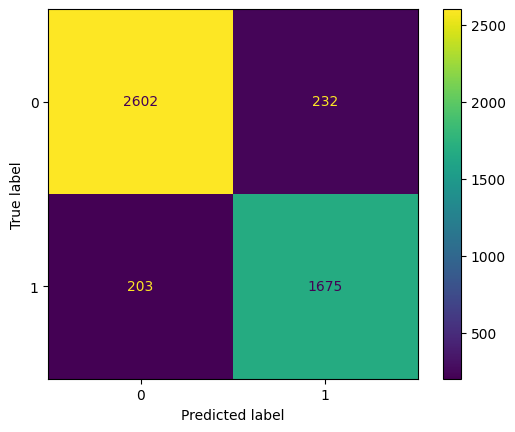

In [70]:
lr = LogisticRegression(max_iter = 10000)
lr.fit(x_train, y_train)
pred = lr.predict(x_test)
print(classification_report(y_test, pred))

lr_cm = ConfusionMatrixDisplay(confusion_matrix(y_test, pred))
lr_cm.plot()
plt.show()

### **Applying Logistic Regression**

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      2834
           1       0.97      0.96      0.97      1878

    accuracy                           0.97      4712
   macro avg       0.97      0.97      0.97      4712
weighted avg       0.97      0.97      0.97      4712



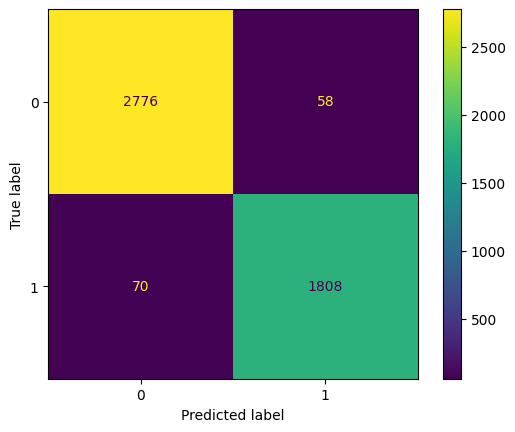

Precision:  0.9689174705251876


In [71]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler

x = tf_df["p_text"]
y= tf_df["label"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size =0.3, random_state=42)

pipeline = Pipeline([
    ("tfidf_vectorizer", TfidfVectorizer(ngram_range = (1,2),
                                            max_features = 10000,
                                            min_df = 2,
                                            max_df = 0.95,
                                            strip_accents = "ascii",
                                            analyzer = "word",
                                            stop_words = "english",
                                            token_pattern = r"(?u)\b\w\w+\b")),
    
    ("MinMaxScaling", MaxAbsScaler()),
    ("random_forest_classifier", LogisticRegression(max_iter = 10000, tol = 0.0001, solver = "saga"))])

pipeline.fit(x_train, y_train)
pred = pipeline.predict(x_test)
print(classification_report(y_test, pred))
rf_cm = ConfusionMatrixDisplay(confusion_matrix(y_test, pred))
rf_cm.plot()
plt.show()
print("Precision: ", precision_score(y_test, pred))

In [72]:
import pickle
pickle.dump(pipeline, open("LR_TF_pipeline.pkl", "wb"))

### **Applying Random Forest Classifier**

              precision    recall  f1-score   support

           0       0.80      0.99      0.88      2834
           1       0.98      0.62      0.76      1878

    accuracy                           0.84      4712
   macro avg       0.89      0.80      0.82      4712
weighted avg       0.87      0.84      0.83      4712



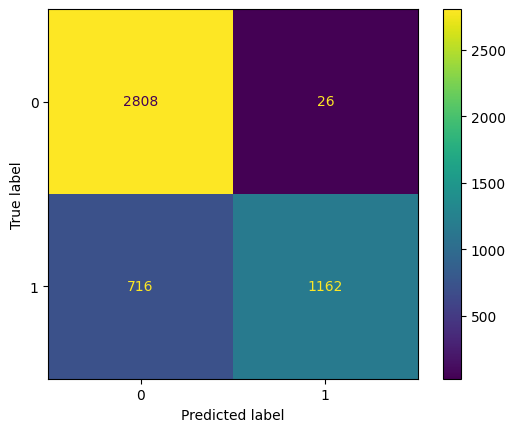

Precision:  0.9781144781144782


In [73]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler

x = tf_df["p_text"]
y= tf_df["label"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size =0.3, random_state=42)

pipeline = Pipeline([
    ("tfidf_vectorizer", TfidfVectorizer(ngram_range = (1,2),
                                            max_features = 10000,
                                            min_df = 2,
                                            max_df = 0.95,
                                            strip_accents = "ascii",
                                            analyzer = "word",
                                            stop_words = "english",
                                            token_pattern = r"(?u)\b\w\w+\b")),
    
    ("MinMaxScaling", MaxAbsScaler()),
    ("random_forest_classifier", RandomForestClassifier(n_estimators = 300,
                                                       max_depth = 7,
                                                       min_samples_split = 5,
                                                       min_samples_leaf = 5,
                                                       warm_start = True))])

pipeline.fit(x_train, y_train)
pred = pipeline.predict(x_test)
print(classification_report(y_test, pred))
rf_cm = ConfusionMatrixDisplay(confusion_matrix(y_test, pred))
rf_cm.plot()
plt.show()

print("Precision: ", precision_score(y_test, pred))

### **Support Vectore Classifier**

              precision    recall  f1-score   support

           0       0.97      0.98      0.98      2834
           1       0.97      0.96      0.97      1878

    accuracy                           0.97      4712
   macro avg       0.97      0.97      0.97      4712
weighted avg       0.97      0.97      0.97      4712



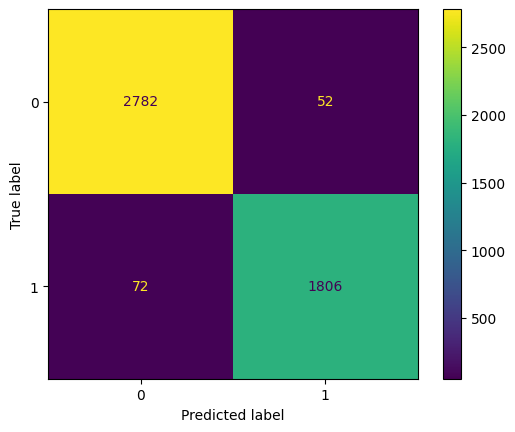

Precision:  0.9720129171151776


In [74]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler

x = tf_df["p_text"]
y= tf_df["label"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size =0.3, random_state=42)

pipeline = Pipeline([
    ("tfidf_vectorizer", TfidfVectorizer(ngram_range = (1,2),
                                            max_features = 8000,
                                            min_df = 2,
                                            max_df = 0.95,
                                            strip_accents = "ascii",
                                            analyzer = "word",
                                            stop_words = "english",
                                            token_pattern = r"(?u)\b\w\w+\b")),
    #("MinMaxScaling", MaxAbsScaler()),
    ("random_forest_classifier", SVC())])

pipeline.fit(x_train, y_train)
pred = pipeline.predict(x_test)
print(classification_report(y_test, pred))
rf_cm = ConfusionMatrixDisplay(confusion_matrix(y_test, pred))
rf_cm.plot()
plt.show()

print("Precision: ", precision_score(y_test, pred))

              precision    recall  f1-score   support

           0       0.97      0.94      0.95      2834
           1       0.92      0.95      0.93      1878

    accuracy                           0.95      4712
   macro avg       0.94      0.95      0.94      4712
weighted avg       0.95      0.95      0.95      4712



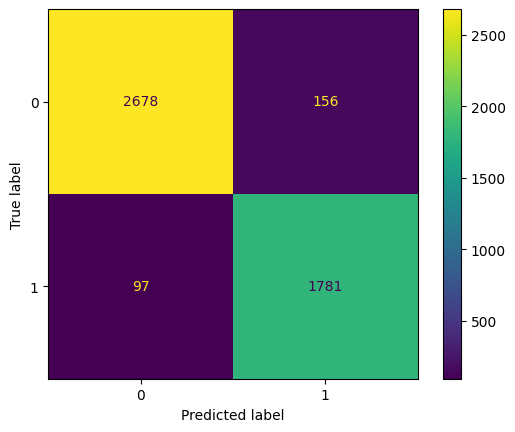

Precision:  0.9194630872483222


In [75]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler

x = tf_df["p_text"]
y= tf_df["label"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size =0.3, random_state=42)

pipeline = Pipeline([
    ("tfidf_vectorizer", TfidfVectorizer(ngram_range = (1,2),
                                            max_features = 10000,
                                            min_df = 2,
                                            max_df = 0.95,
                                            strip_accents = "ascii",
                                            analyzer = "word",
                                            stop_words = "english",
                                            token_pattern = r"(?u)\b\w\w+\b")),
    
    ("MinMaxScaling", MaxAbsScaler()),
    ("random_forest_classifier", GradientBoostingClassifier(n_estimators = 200,
                                                           warm_start = True,
                                                           learning_rate = 0.1,
                                                           max_depth = 5,
                                                           min_impurity_decrease = 0.0001))])

pipeline.fit(x_train, y_train)
pred = pipeline.predict(x_test)
print(classification_report(y_test, pred))
rf_cm = ConfusionMatrixDisplay(confusion_matrix(y_test, pred))
rf_cm.plot()
plt.show()

print("Precision: ", precision_score(y_test, pred))

              precision    recall  f1-score   support

           0       0.92      0.85      0.88      2834
           1       0.80      0.88      0.84      1878

    accuracy                           0.87      4712
   macro avg       0.86      0.87      0.86      4712
weighted avg       0.87      0.87      0.87      4712



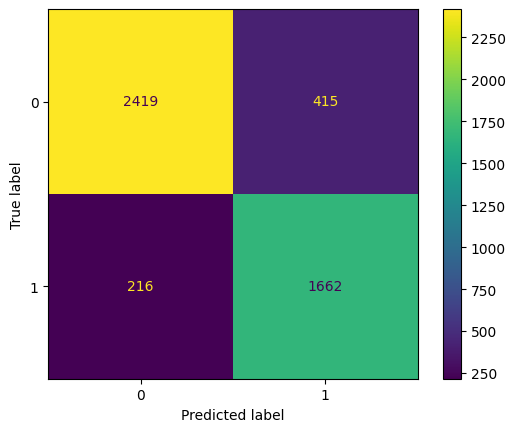

Precision:  0.8001925854597978


In [76]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler

x = tf_df["p_text"]
y= tf_df["label"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size =0.3, random_state=42)

pipeline = Pipeline([
    ("tfidf_vectorizer", TfidfVectorizer(ngram_range = (1,2),
                                            max_features = 8000,
                                            min_df = 2,
                                            max_df = 0.95,
                                            strip_accents = "ascii",
                                            analyzer = "word",
                                            stop_words = "english",
                                            token_pattern = r"(?u)\b\w\w+\b")),
    
    ("MinMaxScaling", MaxAbsScaler()),
    ("random_forest_classifier", AdaBoostClassifier())])

pipeline.fit(x_train, y_train)
pred = pipeline.predict(x_test)
print(classification_report(y_test, pred))
rf_cm = ConfusionMatrixDisplay(confusion_matrix(y_test, pred))
rf_cm.plot()
plt.show()

print("Precision: ", precision_score(y_test, pred))

### **XGBClassifier**

              precision    recall  f1-score   support

           0       0.98      0.95      0.96      2834
           1       0.93      0.96      0.95      1878

    accuracy                           0.96      4712
   macro avg       0.95      0.96      0.96      4712
weighted avg       0.96      0.96      0.96      4712



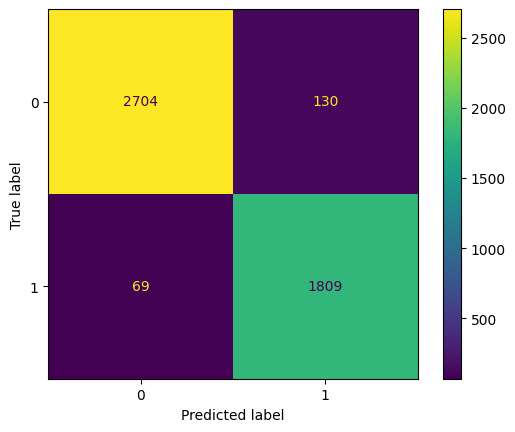

Precision:  0.9329551315110882


In [77]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler

x = tf_df["p_text"]
y= tf_df["label"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size =0.3, random_state=42)

pipeline = Pipeline([
    ("tfidf_vectorizer", TfidfVectorizer(ngram_range = (1,2),
                                            max_features = 8000,
                                            min_df = 2,
                                            max_df = 0.95,
                                            strip_accents = "ascii",
                                            analyzer = "word",
                                            stop_words = "english",
                                            token_pattern = r"(?u)\b\w\w+\b")),
    
    #("MinMaxScaling", MaxAbsScaler()),
    ("random_forest_classifier", XGBClassifier())])

pipeline.fit(x_train, y_train)
pred = pipeline.predict(x_test)
print(classification_report(y_test, pred))
rf_cm = ConfusionMatrixDisplay(confusion_matrix(y_test, pred))
rf_cm.plot()
plt.show()

print("Precision: ", precision_score(y_test, pred))

In [78]:
# from sklearn.preprocessing import MinMaxScaler
# x_train, x_test, y_train, y_test = train_test_split(tv_df, df["label"], test_size=0.3, random_state=42)

# scaler = MinMaxScaler()
# x_train_scaled = scaler.fit_transform(x_train)
# x_test_scaled = scaler.transform(x_test)

In [79]:
# scaled_acc = []
# scaled_prec = []
# for name, model in models.items():
#     model.fit(x_train_scaled, y_train)
#     scaled_pred = model.predict(x_test_scaled)
#     scaled_acc.append(accuracy_score(y_test, scaled_pred))
#     scaled_prec.append(precision_score(y_test, scaled_pred))

# tv_score_df["scaled_precision"] = scaled_prec
# tv_score_df["scaled_accuracy"] = scaled_acc
# tv_score_df

# **Appying Word2Vec text vetorizer of nltk.gensim**

In [80]:
from nltk.tokenize import word_tokenize, sent_tokenize
word_corpus = df["mail"].apply(lambda x: word_tokenize(x))

wv_model = Word2Vec(window = 3, min_count = 1, vector_size=300)
wv_model.build_vocab(word_corpus)
wv_model.train(word_corpus, total_examples = wv_model.corpus_count, epochs = wv_model.epochs)

(12167651, 20134910)

In [81]:
wv_model.wv.most_similar("good")

[('uninspiring', 0.7685225009918213),
 ('great', 0.6416884064674377),
 ('ironment', 0.6247087717056274),
 ('fine', 0.600329577922821),
 ('ominous', 0.5906863808631897),
 ('bad', 0.5832273960113525),
 ('excellent', 0.5536073446273804),
 ('another', 0.5531452298164368),
 ('happen', 0.55087810754776),
 ('though', 0.5435038208961487)]

In [82]:
# all Vectors
wv_model.wv.get_normed_vectors()

array([[ 0.02679727, -0.04221038, -0.04946141, ...,  0.00686506,
        -0.00881794,  0.04120499],
       [-0.04360017,  0.12731291,  0.04319852, ..., -0.07284259,
         0.06186362, -0.09256669],
       [-0.05567947,  0.02031563,  0.06424213, ...,  0.00160629,
         0.04312719, -0.03618524],
       ...,
       [ 0.01724491,  0.00340282, -0.05221167, ..., -0.04749457,
        -0.025709  ,  0.00667604],
       [ 0.01510176,  0.03527449, -0.05462155, ..., -0.08353122,
         0.00051354,  0.00635031],
       [ 0.06297569,  0.04709411, -0.02747678, ..., -0.10065981,
         0.01073636, -0.00211854]], dtype=float32)

In [83]:
wv_model.wv.get_normed_vectors().shape

(114209, 300)

In [84]:
# our dataset vocabulary
wv_model.wv.index_to_key[:10]

['escapenumber',
 'enron',
 'subject',
 'com',
 'escapelong',
 'language',
 'http',
 'please',
 'message',
 'would']

In [85]:
len(wv_model.wv.index_to_key)

114209

### **We convert a sentence into one vector by averaging word vectors.**

In [86]:
def sentence_vector(tokens):
    vectors = []
    for word in tokens:
        if word in wv_model.wv:
            vectors.append(wv_model.wv[word])
    if len(vectors)>0:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(300)

In [87]:
wv_df= np.vstack(word_corpus.apply(sentence_vector))
wv_df.shape

(15705, 300)

In [88]:
x_train, x_test, y_train, y_test = train_test_split(wv_df, y, test_size=0.3, random_state=42)

In [89]:
# models2 = {
#     "LogisticRegression": LogisticRegression(max_iter = 10000),
#     "AdaBoost": AdaBoostClassifier(),
#     "GradientBoosting": GradientBoostingClassifier(),
#     "XGBoost": XGBClassifier(n_estimators = 300),
#     "RandomForest": RandomForestClassifier(n_estimators = 300),
#     "KNN": KNeighborsClassifier(),
#     "DecisionTree": DecisionTreeClassifier(),
#     "SVM": SVC()}

# accuracy = []
# precision = []
# for name, model in models2.items():
#     model.fit(x_train, y_train)
#     wv_pred = model.predict(x_test)
#     accuracy.append(accuracy_score(y_test, wv_pred))
#     precision.append(precision_score(y_test, wv_pred))

# pd.DataFrame({"model":models2.keys(), "wv_precision":precision, "wv_accuracy":accuracy})

In [90]:
# lr = LogisticRegression(max_iter = 10000)
# lr.fit(x_train, y_train)
# lr_pred = lr.predict(x_test)
# print(classification_report(y_test, lr_pred))

# lr_cm = ConfusionMatrixDisplay(confusion_matrix(y_test, lr_pred))
# lr_cm.plot()
# plt.show()

In [91]:
# r = RandomForestClassifier(n_estimators = 300)
# r.fit(x_train, y_train)
# r_pred = r.predict(x_test)
# print(classification_report(y_test, r_pred))

# lr_cm = ConfusionMatrixDisplay(confusion_matrix(y_test, r_pred))
# lr_cm.plot()
# plt.show()

## **XGBClassifier**

In [92]:
# lr = XGBClassifier(n_estimators = 300)

# lr.fit(x_train, y_train)
# lr_pred = lr.predict(x_test)
# print(classification_report(y_test, lr_pred))

# lr_cm = ConfusionMatrixDisplay(confusion_matrix(y_test, lr_pred))
# lr_cm.plot()
# plt.show()

In [93]:
import sklearn
import matplotlib
print("Numpy: ", np.__version__)
print("Pandas: ", pd.__version__)
print("Sklearn:", sklearn.__version__)
print("matplotlib: ", matplotlib.__version__)

Numpy:  2.0.2
Pandas:  2.3.3
Sklearn: 1.6.1
matplotlib:  3.10.0
